In [4]:
import matplotlib.pyplot as plt
import numpy as np
import cvxpy as cp
from EVFleet import * 
import pandas as pd

In [7]:
def create_energy_set(start, M, H, pv, wt):
    days = 365 // M -1
    q = np.zeros((M, H))
    Q = np.zeros((M, days * 24))
    for m in range(M):
        start_idx = m * days * 24
        end_idx = (m + 1) * days * 24
        Q[m, :] = pv[start_idx:end_idx] + wt[start_idx:end_idx]
        q[m, :] = Q[m, start:start+H]

    return q

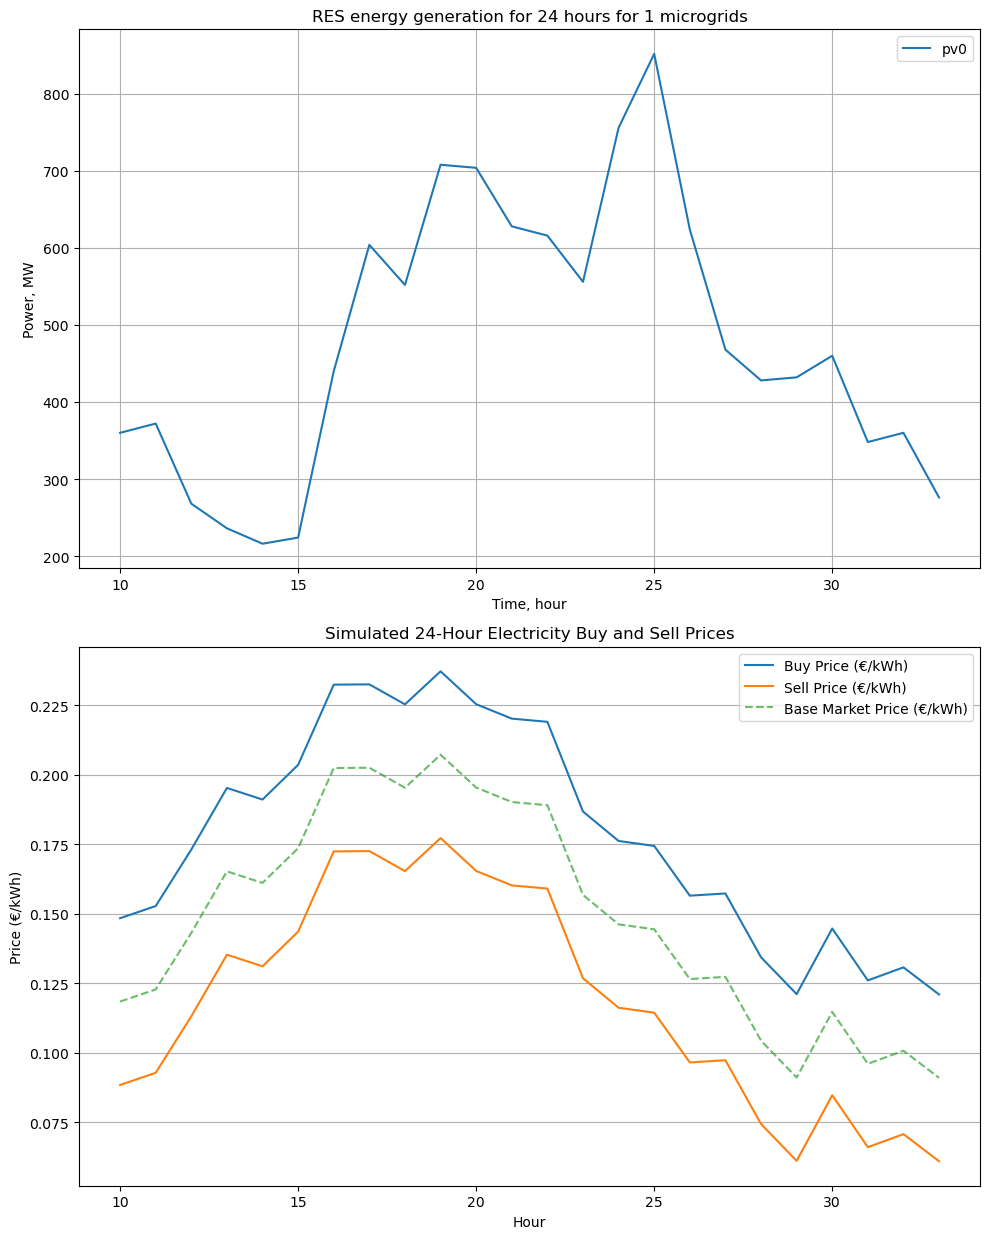

In [119]:
DAYS = 1
H=24
N=5
M=1
start = 10

# Set seed for reproducibility
np.random.seed(42)

hours = np.arange(start, start + H)
base_price = 0.15
amplitude = 0.10

noise = np.random.normal(0, 0.01, size=24*DAYS)
# Symmetric price
prices = base_price + amplitude * (
    np.sin((hours - 8) / 24 * 2 * np.pi) + np.sin((hours - 18) / 24 * 2 * np.pi)
) + noise
prices = np.clip(prices, 0.05, None)
    
# Add asymmetric buy/sell prices
margin = 0.03
c = prices + margin
p = prices - margin
p = np.clip(p, 0.01, None)  # Prevent negative prices

# Load CSV data
pv_energy = '2023_photovoltaic_total_at.csv'  # Replace with your actual file path
wt_energy = '2023_windpower_total_at.csv'  # Replace with your actual file path

pv = pd.read_csv(pv_energy, delimiter=';')
wt = pd.read_csv(wt_energy, delimiter=';')

pv_arr = pv['Power (MW)'].to_numpy()
wt_arr = wt['Power (MW)'].to_numpy()


q = create_energy_set(start, M, H*DAYS, pv_arr, wt_arr)

# Plotting
fig, axs = plt.subplots(2, 1, figsize=(10, 12.5))  # 1 row, 2 columns

axs[0].set_title(f'RES energy generation for {H*DAYS} hours for {M} microgrids')
for m in range(M): 
    axs[0].plot(np.arange(start, start+H*DAYS), q[m,:], label=f"pv{m}")
axs[0].legend()
axs[0].set_xlabel('Time, hour')
axs[0].set_ylabel('Power, MW')
axs[0].grid(True)
# First subplot: Buy and Sell Prices
axs[1].plot(hours, c, label='Buy Price (€/kWh)')
axs[1].plot(hours, p, label='Sell Price (€/kWh)')
axs[1].plot(hours, prices, label='Base Market Price (€/kWh)', linestyle='--', alpha=0.7)
axs[1].set_title("Simulated 24-Hour Electricity Buy and Sell Prices")
axs[1].set_xlabel("Hour")
axs[1].set_ylabel("Price (€/kWh)")
axs[1].grid(axis='y')
axs[1].legend()

plt.tight_layout()
plt.savefig("MPC environmental parameters", dpi=300)
plt.show()

In [121]:
random_cars = False
L_usage = np.zeros((M,N,DAYS+1,4), dtype='int')
if random_cars:
    fleet = EVFleet(xlsx_path='EV_UsageProfile.xlsx', num_vehicles=N*M)
    results = fleet.simulate_multiple_days(num_days=2)
    
    
    for row in results:
        L_usage[row['EV'] // N, row['EV'] % N, row['Day']-1, 0] = int(row['Initial SoC'])
        L_usage[row['EV'] // N, row['EV'] % N, row['Day']-1, 1] = int(row['Goal (kWh)'])
        L_usage[row['EV'] // N, row['EV'] % N, row['Day']-1, 2] = int(row['Arrival (h)']) + 24*(row['Day']-1) 
        L_usage[row['EV'] // N, row['EV'] % N, row['Day']-1, 3] = int(row['Departure (h)']) + 24*(row['Day']) if int(row['Departure (h)']) + 24*(row['Day']) < 34*(row['Day']) else 33*(row['Day'])
    
        print(row['EV'] // N, row['EV'] % N, L_usage[row['EV'] // N, row['EV'] % N, row['Day']-1, :])
else:
    L_usage[0,0,0,:] = [1416, 8000, 16, 30]
    L_usage[0,1,0,:] = [1301, 8000, 14, 31]
    L_usage[0,2,0,:] = [1004, 8000, 13, 30]
    L_usage[0,3,0,:] = [1391, 8000, 17, 31]
    L_usage[0,4,0,:] = [1263, 4000, 11, 33]

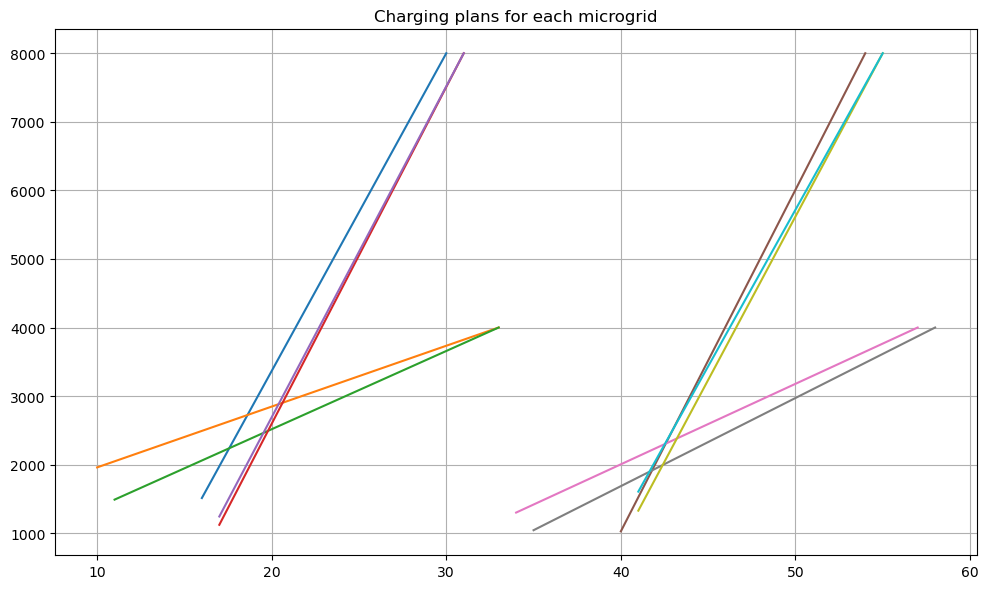

In [117]:
#fig, axs = plt.subplots(2, 1, figsize=(10,12.5))
plt.figure(figsize = (10,6))
for d in range(2):
    for m in range(M):
        for n in range(N):
            L_init, L_target, L_arrival, L_dep = L_usage[m,n,d,:]
            y = [L_init, L_target]
            x = [L_arrival, L_dep]
            plt.plot(x,y)
            plt.grid(True)
plt.title("Charging plans for each microgrid");
plt.tight_layout()
plt.savefig("Charging plans for each microgrid for 2 days", dpi=300)
plt.show()

L_target = L_usage[:,:,0,1]
L_init = L_usage[:,:,0,0]
L_arrival = L_usage[:,:,0,2]
L_depart = L_usage[:,:,0,3]

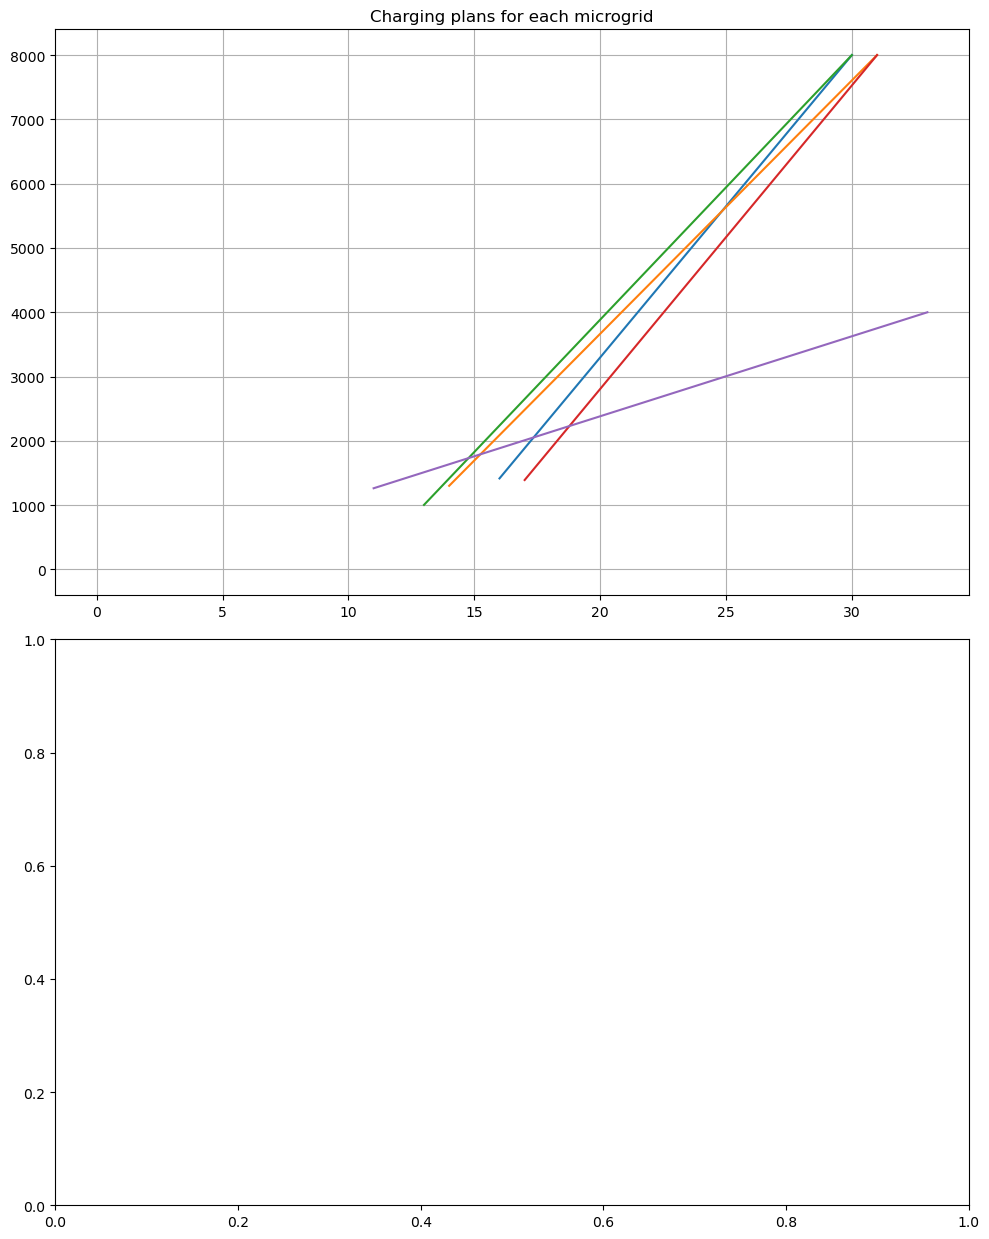

In [123]:
fig, axs = plt.subplots(2, 1, figsize=(10,12.5))

for d in range(2):
    for m in range(M):
        for n in range(N):
            L_init, L_target, L_arrival, L_dep = L_usage[m,n,d,:]
            y = [L_init, L_target]
            x = [L_arrival, L_dep]
            axs[m].plot(x,y)
            axs[m].grid(True)
axs[0].set_title("Charging plans for each microgrid");
plt.tight_layout()
plt.savefig("Charging plans for each microgrid", dpi=300)
plt.show()

L_target = L_usage[:,:,0,1]
L_init = L_usage[:,:,0,0]
L_arrival = L_usage[:,:,0,2]
L_depart = L_usage[:,:,0,3]

In [125]:
# Parameters

c1 = 5
np.random.seed(42)


L_min = np.ones((N, H)) * 0
L_max = np.ones((N, H)) * 10000

d_min = np.zeros((N, H))
d_max = np.ones((N, H)) * 1000

f_min = np.zeros((N, H))
f_max = np.ones((N, H)) * 1000

l_min = np.zeros((N, H))
l_max = np.ones((N, H)) * 1000

m_min = np.zeros((N, H))
m_max = np.ones((N, H)) * 1000

# Decision variables for each agent
x = [cp.Variable(5*H) for _ in range(N)]

constraints = []
objective = 0
cost_terms = []
penalty_terms = []

for n in range(N):
    d = x[n][:H]
    f = x[n][H:2*H]
    l = x[n][2*H:3*H]
    m = x[n][3*H:4*H]
    L = x[n][4*H:]

    constraints += [
        L >= L_min[n],
        L <= L_max[n],
        d >= d_min[n],
        d <= d_max[n],
        f >= f_min[n],
        f <= f_max[n],
        l >= l_min[n],
        l <= l_max[n],
        m >= m_min[n],
        m <= m_max[n]
    ]

    constraints += [
             L[L_arrival[0,n]-start] == L_init[0][n] + l[L_arrival[0,n]-start] - m[L_arrival[0,n]-start]
    ]

    start_time = L_arrival[0][n]-start
    end_time = L_depart[0][n]-start

    for h in range(1, H):
            constraints += [
                L[h] == L[h-1] + l[h] - m[h],
                cp.abs(l[h-1] - l[h]) <= 500,
                cp.abs(m[h-1] - m[h]) <= 500,
                cp.abs(d[h-1] - d[h]) <= 500,
                cp.abs(f[h-1] - f[h]) <= 500,
            ]
            
    for h in range(start, start + H):
            if h >= L_depart[0,n]:
                constraints += [
                    l[h-start] == 0,
                    m[h-start] == 0,
                    d[h-start] == 0
                ]
            if h <= L_arrival[0,n]:
                constraints += [
                    l[h-start] == 0,
                    m[h-start] == 0,
                    d[h-start] == 0
                ]

    cost_term = c1*cp.sum(cp.multiply(c, d) / q[0] - cp.multiply(p, f) / q[0])
    penalty_term = cp.sum_squares(L[end_time] - L_target[0][n])
    objective += cost_term + penalty_term
    cost_terms.append(cost_term)
    penalty_terms.append(penalty_term)

#overall energy consumption
for h in range(H):
    constraints +=[q[0][h] == -cp.sum(x, axis=0)[:H][h] + cp.sum(x, axis=0)[H:2*H][h] + cp.sum(x, axis=0)[2*H:3*H][h] - cp.sum(x, axis=0)[3*H:4*H][h]]
"""
for h in range(1, H):
    #rate of change for d and f
    constraints +=[cp.abs(cp.sum(x,axis=0)[:H][h-1] - cp.sum(x,axis=0)[:H][h]) <= 1,
                   cp.abs(cp.sum(x,axis=0)[H:2*H][h-1] - cp.sum(x,axis=0)[H:2*H][h]) <= 1
                  ]
"""
# Solve the problem
prob = cp.Problem(cp.Minimize(objective), constraints)
prob.solve(solver="CLARABEL")

# Collect data for plotting
d_history = np.array([x[n][:H].value for n in range(N)])
f_history = np.array([x[n][H:2*H].value for n in range(N)])
l_history = np.array([x[n][2*H:3*H].value for n in range(N)])
m_history = np.array([x[n][3*H:4*H].value for n in range(N)])
L_history = np.array([x[n][4*H:].value for n in range(N)])

for n in range(N):
    print(f"Objective functions in Agent {n}: "
          f"Cost term: {cost_terms[n].value:.2f}, "
          f"Penalty term: {penalty_terms[n].value:.2f}")

print(f"overall objective: {objective.value}")

Objective functions in Agent 0: Cost term: 2.88, Penalty term: 0.00
Objective functions in Agent 1: Cost term: 3.76, Penalty term: 0.00
Objective functions in Agent 2: Cost term: 2.88, Penalty term: 0.00
Objective functions in Agent 3: Cost term: 3.76, Penalty term: 0.00
Objective functions in Agent 4: Cost term: 3.70, Penalty term: 0.00
overall objective: 16.9846199094673


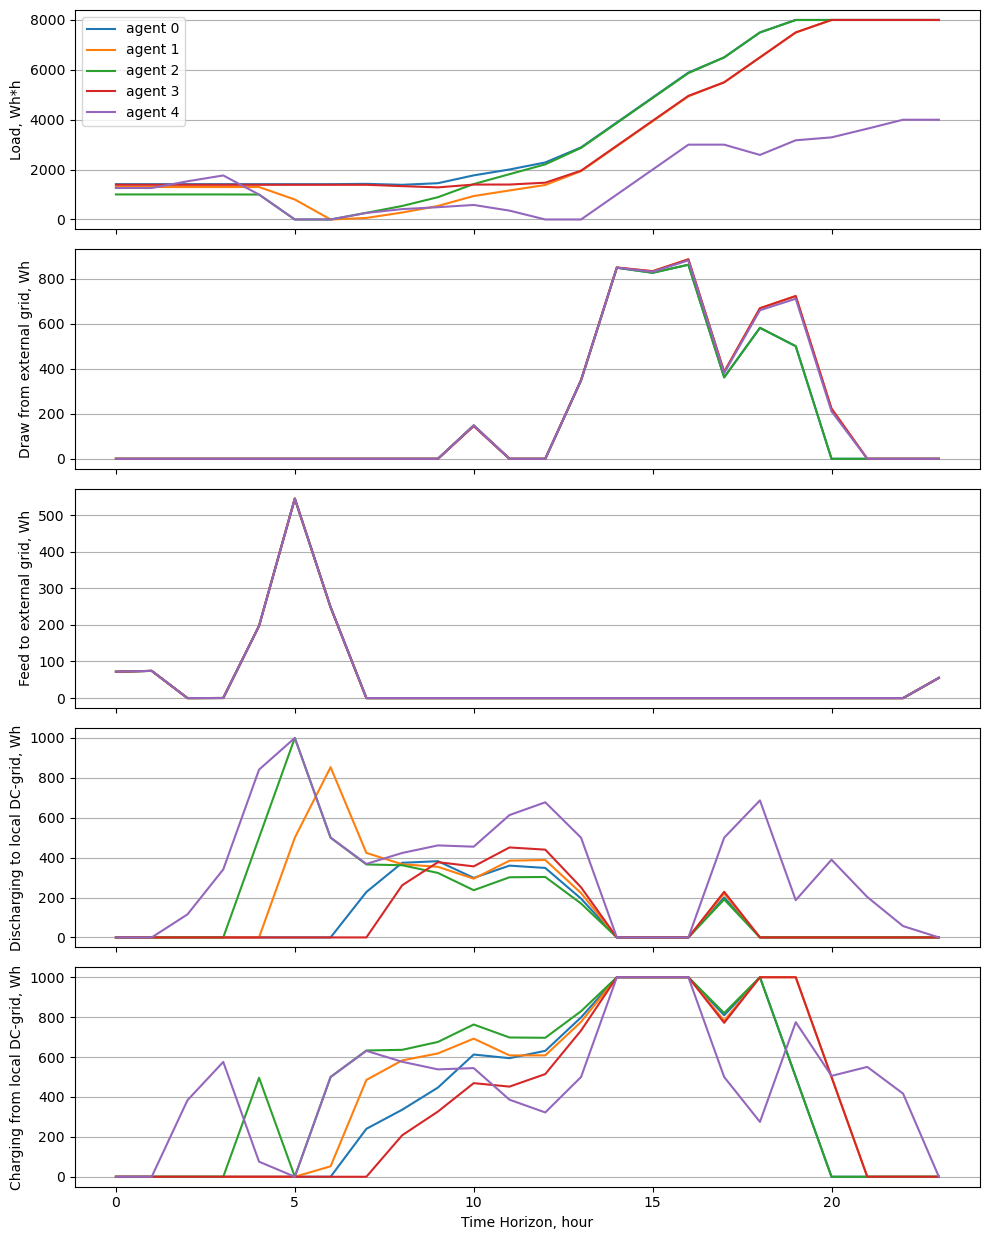

In [127]:
# Plotting
fig, axes = plt.subplots(5, 1, figsize=(10, 5*2.5), sharex=True)

for n in range(N):
    #axes[0].plot(np.full(H,L_target[n]))
    axes[0].plot(L_history[n], label =f'agent {n}')
    axes[0].grid(axis='y')
    axes[0].legend()
    axes[0].set_ylabel("Load, Wh*h")

for n in range(N):
    axes[1].plot(d_history[n])
    axes[1].grid(axis='y')
    axes[1].set_ylabel("Draw from external grid, Wh")

for n in range(N):
    axes[2].plot(f_history[n])
    axes[2].grid(axis='y')
    axes[2].set_ylabel("Feed to external grid, Wh")
    
for n in range(N):
    axes[3].plot(m_history[n])
    axes[3].grid(axis='y')
    axes[3].set_ylabel("Discharging to local DC-grid, Wh")
    
for n in range(N):
    axes[4].plot(l_history[n])
    axes[4].grid(axis='y')
    axes[4].set_ylabel("Charging from local DC-grid, Wh")
    

axes[-1].set_xlabel('Time Horizon, hour')
plt.tight_layout()
plt.savefig("Centralised framework with data", dpi=300)
plt.show()

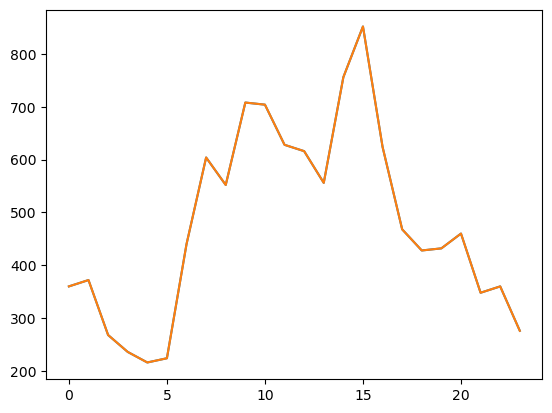

In [47]:
plt.plot(-np.sum(d_history,axis=0)+np.sum(f_history,axis=0)+np.sum(l_history,axis=0)-np.sum(m_history,axis=0))
plt.plot(q[0])

In [56]:
for n in range(N):
    print(f"Error between target and real load of {1+n} agent is {100 * (L_target[0][n] - L_history[n][L_depart[0][n]-start])/L_target[0][n]:.2f}%")

Error between target and real load of 1 agent is 0.00%
Error between target and real load of 2 agent is 0.00%
Error between target and real load of 3 agent is 0.00%
Error between target and real load of 4 agent is 0.00%
Error between target and real load of 5 agent is 0.00%


In [52]:
total_cost = 0

cost = np.sum(c * d_history / q[0] - p * f_history / q[0]) #+ (L_target - L_history[:,-1]).T@(L_target - L_history[:,-1])
print(cost)

3.3969233548682327


In [90]:
np.sum(c @ np.sum(d_history,axis=0)/q - p @ np.sum(f_history,axis=0)/q)

93.65957073842986

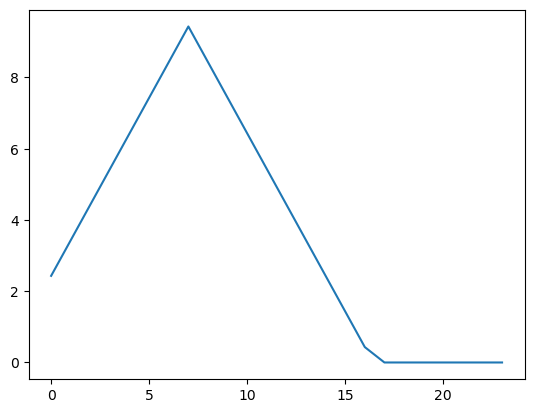

In [92]:
plt.plot(np.sum(d_history,axis=0))